In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [9]:
ndvi_path = "/Users/tillweiss/Desktop/MODSNOW/data/NDVI_nc/NDVI_clean.nc"
ds_ndvi = xr.open_dataset(ndvi_path, engine="h5netcdf")

ndvi = ds_ndvi["ndvi_clean"]

ndvi_doy_start = 200
ndvi_doy_end = 260

doy = ndvi["time"].dt.dayofyear
mask = (doy >= ndvi_doy_start) & (doy <= ndvi_doy_end)

ndvi_window = ndvi.where(mask)
mean_ndvi = ndvi_window.mean(dim="time", skipna=True)

In [10]:
downsample = 2  # set to 4 or 8 if needed

if downsample > 1:
    mean_ndvi = mean_ndvi.coarsen(lat=downsample, lon=downsample, boundary="trim").mean()

In [11]:
reg_path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_ndvi_sca_regression_annual_full_ds2.nc"
ds_reg = xr.open_dataset(reg_path)

r2 = ds_reg["r2"]

/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib

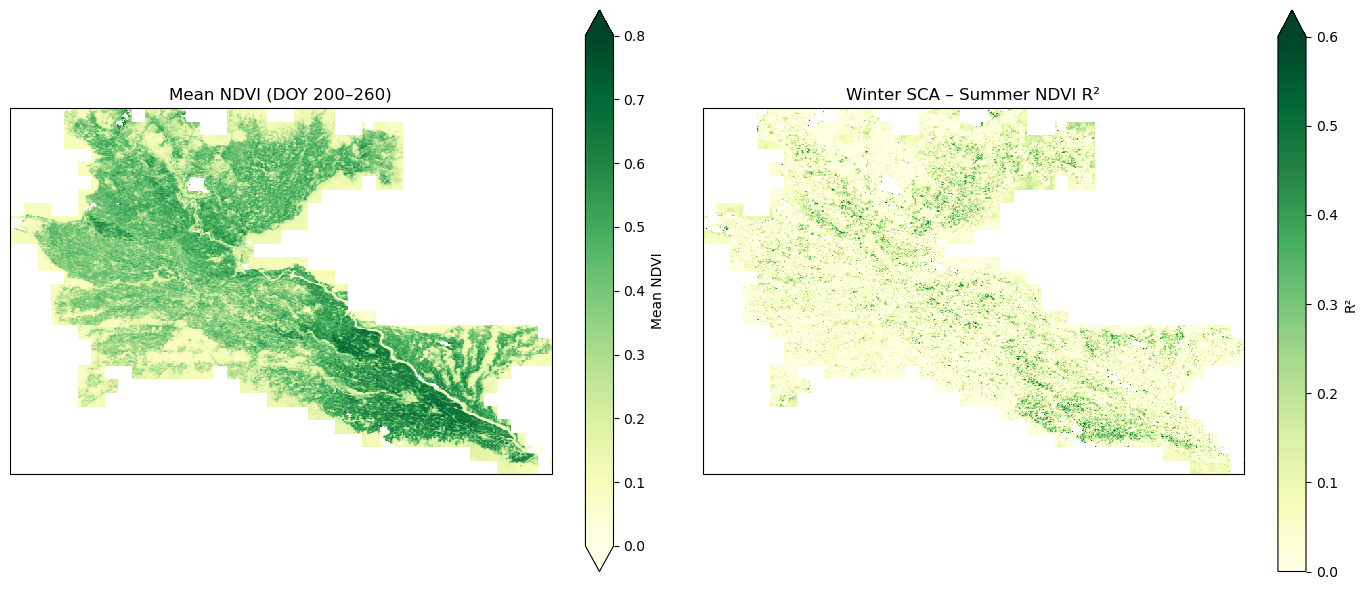

In [13]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# ---- LEFT: Mean NDVI ----
mean_ndvi.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=0.8,
    cbar_kwargs={'label': 'Mean NDVI'}
)

axes[0].coastlines()
axes[0].set_title('Mean NDVI (DOY 200–260)')


# ---- RIGHT: R² ----
r2.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=0.6,
    cbar_kwargs={'label': 'R²'}
)

axes[1].coastlines()
axes[1].set_title('Winter SCA – Summer NDVI R²')

plt.savefig('ndvi-r2-comp.png', dpi=300)

plt.tight_layout()
plt.show()